# CA4 - Jake Bonavia, Faisal Alessa

## Section 1 - Data Souce and Contents

In this section, the dataset used for model development is loaded and examined. The data originates from the U.S. Census Bureau and is the same dataset utilized in CA03. The objective is to prepare the data for ensemble modeling by identifying its structure, separating training and testing datasets using the predefined flag column, and isolating predictor variables from the target variable.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/ArinB/MSBA-CA-03-Decision-Trees/master/census_data.csv"
df = pd.read_csv(url)

df.shape

(48842, 11)

In [2]:
df.columns

Index(['hours_per_week_bin', 'occupation_bin', 'msr_bin', 'capital_gl_bin',
       'race_sex_bin', 'education_num_bin', 'education_bin', 'workclass_bin',
       'age_bin', 'flag', 'y'],
      dtype='object')

In [3]:
train_df = df[df["flag"] == "train"]
test_df  = df[df["flag"] == "test"]

train_df.shape, test_df.shape

((32561, 11), (16281, 11))

In [4]:
X_train = train_df.drop(["y", "flag"], axis=1)
y_train = train_df["y"]

X_test  = test_df.drop(["y", "flag"], axis=1)
y_test  = test_df["y"]

X_train.shape, X_test.shape

((32561, 9), (16281, 9))

The dataset contains 48,842 observations and 11 columns, including nine predictor variables, one binary target variable (y), and one indicator column (flag). The data was split into 32,561 training observations and 16,281 testing observations using the flag column, as required by the assignment. The predictor variables were separated from the target variable in preparation for model training and evaluation in the subsequent sections.

## Section 2 - Finding Optimal Value of a key Ensemble Method Hyper-parameter

In this section, the objective is to determine the optimal value of a key hyperparameter for the Random Forest ensemble model, namely the number of estimators (n_estimators). The number of estimators represents the number of decision trees built within the ensemble. Increasing the number of trees can improve model stability and predictive performance, but beyond a certain point, improvements may become marginal while computational cost increases. To identify an appropriate value, Accuracy and AUC were evaluated across different values of n_estimators.

In [5]:
import pandas as pd

# One hot encode both
X_train_enc = pd.get_dummies(X_train, drop_first=False)
X_test_enc  = pd.get_dummies(X_test, drop_first=False)

# To Make sure test has the same columns as train
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

X_train_enc.shape, X_test_enc.shape

((32561, 36), (16281, 36))

In [6]:
y_train_num = pd.to_numeric(y_train)
y_test_num  = pd.to_numeric(y_test)

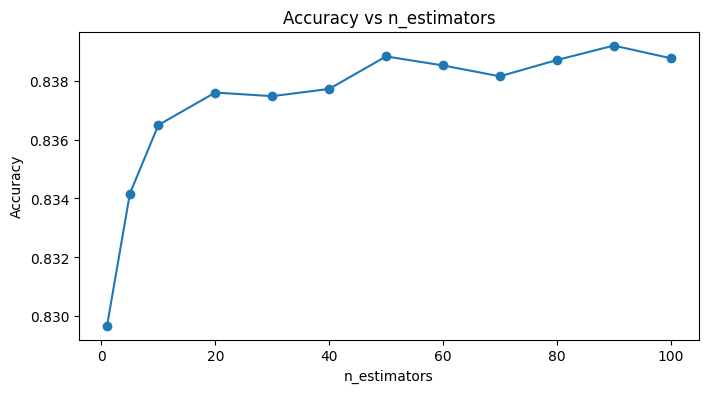

In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

results_acc = []
n_estimators_options = [1,5,10,20,30,40,50,60,70,80,90,100]

for n in n_estimators_options:
    model = RandomForestClassifier(n_estimators=n, random_state=101)
    model.fit(X_train_enc, y_train_num)

    y_pred = model.predict(X_test_enc)
    acc = np.mean(y_test_num == y_pred)
    results_acc.append(acc)

plt.figure(figsize=(8,4))
plt.plot(n_estimators_options, results_acc, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Accuracy vs n_estimators")
plt.show()

The Accuracy curve shows a sharp improvement when increasing the number of estimators from 1 to approximately 20 trees. Beyond this range, the improvements become gradual and begin to stabilize after around 50–60 trees. The highest observed Accuracy is approximately 0.839, indicating that additional trees beyond this point contribute very little to overall classification accuracy.

In [ ]:
results_auc = []

for n in n_estimators_options:
    model = RandomForestClassifier(n_estimators=n, random_state=101)
    model.fit(X_train_enc, y_train_num)

    y_prob = model.predict_proba(X_test_enc)[:, 1]
    auc = roc_auc_score(y_test_num, y_prob)
    results_auc.append(auc)

plt.figure(figsize=(8,4))
plt.plot(n_estimators_options, results_auc, marker="o")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.title("AUC vs n_estimators")
plt.show()

The AUC curve follows a similar pattern, with rapid improvement at lower values of n_estimators and gradual stabilization as the number of trees increases. The maximum AUC achieved is approximately 0.881. Since AUC measures the model’s ability to distinguish between income classes, this indicates strong discriminative performance. Similar to Accuracy, improvements beyond 60–80 estimators are marginal.

In [ ]:
final_model = RandomForestClassifier(n_estimators=80, random_state=101)
final_model.fit(X_train_enc, y_train_num)

y_pred = final_model.predict(X_test_enc)
y_prob = final_model.predict_proba(X_test_enc)[:,1]

print("Final Accuracy:", accuracy_score(y_test_num, y_pred))
print("Final AUC:", roc_auc_score(y_test_num, y_prob))

Based on the observed behavior of both Accuracy and AUC, the performance of the Random Forest model stabilizes beyond approximately 60 trees. While slightly higher values such as 90 or 100 trees show minimal improvements, these gains are not substantial relative to the increased computational cost. Therefore, n_estimators = 80 was selected as the optimal value, balancing predictive performance and efficiency. Using this value, the final model achieved an Accuracy of 0.8387 and an AUC of 0.8806 on the test dataset.

## Section 3 - Building a Random Forest Model

In this section, a Random Forest classifier is trained using the predefined training and testing datasets. Unlike Section 2, where smaller values of n_estimators were explored, this section evaluates larger values ranging from 50 to 500 estimators. The objective is to analyze how the model behaves as the number of trees increases significantly and to determine whether an optimal value exists within this extended range. All other hyperparameters are kept at their default settings to isolate the effect of n_estimators.

In [ ]:
 rf_results_acc = []
rf_results_auc = []

rf_n_values = [50,100,150,200,250,300,350,400,450,500]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

for n in rf_n_values:
    rf_model = RandomForestClassifier(n_estimators=n, random_state=101)
    rf_model.fit(X_train_enc, y_train_num)

    y_pred = rf_model.predict(X_test_enc)
    y_prob = rf_model.predict_proba(X_test_enc)[:,1]

    acc = accuracy_score(y_test_num, y_pred)
    auc = roc_auc_score(y_test_num, y_prob)

    rf_results_acc.append(acc)
    rf_results_auc.append(auc)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(rf_n_values, rf_results_acc, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest: Accuracy vs n_estimators")
plt.show()

The Accuracy curve exhibits minor fluctuations across the range of 50 to 500 estimators. Although the values vary slightly, there is no consistent upward trend. The magnitude of variation is very small, indicating that the model performance has largely stabilized. T

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(rf_n_values, rf_results_auc, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.title("Random Forest: AUC vs n_estimators")
plt.show()

The AUC curve shows a slight increase at lower values within the range but stabilizes beyond approximately 300 estimators. While the highest AUC is achieved near 500 estimators, the incremental improvement compared to values around 300–400 estimators is minimal. This indicates diminishing returns as more trees are added to the ensemble.

1. Observations about Classifier Behavior

As the number of estimators increases from 50 to 500, the Random Forest classifier demonstrates highly stable performance. Both Accuracy and AUC show only marginal variation, indicating that the ensemble has already achieved sufficient variance reduction. Additional trees primarily enhance stability and reduce randomness in predictions rather than substantially improving predictive power. This behavior aligns with the theoretical understanding of Random Forests, where performance typically plateaus after a moderate number of trees.

2. Is There an Optimal Value Within the Given Range?

Within the evaluated range, there is no sharply defined optimal value, as performance metrics remain largely consistent. Although the highest AUC occurs near 500 estimators, the improvement relative to 300–400 estimators is negligible. Considering the trade-off between computational cost and performance gain, a value between 300 and 400 estimators can be considered optimal, as it provides near-maximum performance without unnecessary computational overhead.

## Section 4 - Building AdaBoost, Gradient Boost, and XGB



### Part 1 - AdaBoost

In this section, the AdaBoost classifier is trained using the same training and testing datasets. AdaBoost is a boosting-based ensemble method that sequentially builds weak learners, focusing more on previously misclassified observations. The number of estimators (n_estimators) is varied from 50 to 500 to analyze how increasing the number of boosting iterations affects predictive performance. All other hyperparameters are kept at their default settings.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
ada_acc = []
ada_auc = []

n_values = [50,100,150,200,250,300,350,400,450,500]

for n in n_values:
    ada = AdaBoostClassifier(n_estimators=n, random_state=101)
    ada.fit(X_train_enc, y_train_num)

    y_pred = ada.predict(X_test_enc)
    y_prob = ada.predict_proba(X_test_enc)[:,1]

    ada_acc.append(accuracy_score(y_test_num, y_pred))
    ada_auc.append(roc_auc_score(y_test_num, y_prob))

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(n_values, ada_acc, marker='o')
plt.title("AdaBoost: Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

The Accuracy curve for AdaBoost shows a steady improvement as the number of estimators increases. Unlike Random Forest, AdaBoost continues to benefit from additional estimators over a larger range. However, the rate of improvement gradually slows down at higher values, indicating convergence.

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(n_values, ada_auc, marker='o')
plt.title("AdaBoost: AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.show()

The AUC curve follows a similar upward trend, increasing more noticeably at lower values of n_estimators and stabilizing as the number of boosting rounds increases. This suggests that AdaBoost improves class discrimination capability as more weak learners are added, but gains diminish at higher values.

AdaBoost demonstrates a more progressive improvement compared to Random Forest. Since boosting methods sequentially correct previous errors, increasing the number of estimators continues refining the model. However, after a certain point, additional estimators provide only marginal improvements.

### Part 2 - Gradient Boosting

Gradient Boosting is another boosting-based ensemble technique that builds models sequentially, but instead of adjusting sample weights, it minimizes residual errors directly through gradient descent. Similar to AdaBoost, the number of estimators is varied from 50 to 500 to observe its impact on Accuracy and AUC.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb_acc = []
gb_auc = []

for n in n_values:
    gb = GradientBoostingClassifier(n_estimators=n, random_state=101)
    gb.fit(X_train_enc, y_train_num)

    y_pred = gb.predict(X_test_enc)
    y_prob = gb.predict_proba(X_test_enc)[:,1]

    gb_acc.append(accuracy_score(y_test_num, y_pred))
    gb_auc.append(roc_auc_score(y_test_num, y_prob))

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(n_values, gb_acc, marker='o')
plt.title("Gradient Boost: Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(n_values, gb_auc, marker='o')
plt.title("Gradient Boost: AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.show()

The Accuracy curve for Gradient Boosting shows a smooth and consistent upward trend as the number of estimators increases. The improvement is more stable and less fluctuating compared to AdaBoost, indicating stronger convergence behavior.

The AUC curve increases steadily and achieves the highest values among the models tested. This suggests that Gradient Boosting provides strong class separation capability and benefits significantly from additional boosting iterations within the tested range.

Gradient Boosting exhibits consistent performance improvement as estimators increase. Since it directly optimizes residual errors, it tends to achieve stronger predictive performance compared to both Random Forest and AdaBoost. The model appears to converge smoothly without large fluctuations.

### Part 3 - XGBoost

XGBoost (Extreme Gradient Boosting) is an advanced implementation of gradient boosting that incorporates regularization and optimized tree construction. It is known for strong predictive performance and computational efficiency. The same range of n_estimators (50 to 500) is evaluated to analyze its impact on model performance.

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
import re

def sanitize_columns(df):
    df = df.copy()
    df.columns = [re.sub(r'[\[\]<>]', '', str(c)) for c in df.columns]  # remove [, ], <, >
    df.columns = [c.replace(" ", "_") for c in df.columns]            # replace spaces
    return df

X_train_xgb = sanitize_columns(X_train_enc)
X_test_xgb  = sanitize_columns(X_test_enc)

# make sure alignment stays perfect
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

X_train_xgb.shape, X_test_xgb.shape

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

xgb_acc = []
xgb_auc = []

n_values = [50,100,150,200,250,300,350,400,450,500]

for n in n_values:
    xgb = XGBClassifier(
        n_estimators=n,
        random_state=101,
        eval_metric="logloss"
    )
    xgb.fit(X_train_xgb, y_train_num)

    y_pred = xgb.predict(X_test_xgb)
    y_prob = xgb.predict_proba(X_test_xgb)[:, 1]

    xgb_acc.append(accuracy_score(y_test_num, y_pred))
    xgb_auc.append(roc_auc_score(y_test_num, y_prob))

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(n_values, xgb_acc, marker='o')
plt.title("XGBoost: Accuracy vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(n_values, xgb_auc, marker='o')
plt.title("XGBoost: AUC vs n_estimators")
plt.xlabel("n_estimators")
plt.ylabel("AUC")
plt.show()

The Accuracy curve for XGBoost shows a steady improvement pattern similar to Gradient Boosting. Performance increases consistently with more estimators and stabilizes at higher values.

The AUC curve increases steadily and reaches high values, indicating strong classification capability. Although XGBoost performs very similarly to Gradient Boosting, its performance is slightly lower in this particular dataset under default hyperparameters.

XGBoost demonstrates strong and stable performance across the tested range. It benefits from additional estimators, though improvements become marginal at higher values. The model shows good convergence and competitive predictive performance.

## 5. Comparison of Best Accuracy and AUC Across Models

In this section, the best-performing configurations of the four ensemble models — Random Forest, AdaBoost, Gradient Boosting, and XGBoost are compared. For each model, the number of estimators that produced the highest Accuracy and the highest AUC within the tested range is identified. This comparison provides a clear overview of overall model performance and helps determine which ensemble technique performs best on this dataset.

In [ ]:
# Random Forest
best_rf_acc = max(rf_results_acc)
best_rf_auc = max(rf_results_auc)

# AdaBoost
best_ada_acc = max(ada_acc)
best_ada_auc = max(ada_auc)

# Gradient Boost
best_gb_acc = max(gb_acc)
best_gb_auc = max(gb_auc)

# XGBoost
best_xgb_acc = max(xgb_acc)
best_xgb_auc = max(xgb_auc)

In [ ]:
import pandas as pd

comparison_table = pd.DataFrame({
    "Random Forest": [best_rf_acc, best_rf_auc],
    "AdaBoost": [best_ada_acc, best_ada_auc],
    "Gradient Boost": [best_gb_acc, best_gb_auc],
    "XGB": [best_xgb_acc, best_xgb_auc]
}, index=["Accuracy", "AUC"])

comparison_table

A comparative analysis of the four ensemble models Random Forest, AdaBoost, Gradient Boosting, and XGBoost reveals noticeable differences in predictive performance. Among the models evaluated, Gradient Boosting achieved the highest overall performance, with an Accuracy of 0.8472 and an AUC of 0.8990, indicating superior classification capability and class discrimination power.


AdaBoost and XGBoost also demonstrated strong performance, achieving Accuracy values of 0.8458 and 0.8442, respectively, and AUC values above 0.896. These results show that boosting based methods generally outperform the bagging based Random Forest approach on this dataset. Boosting algorithms improve model performance by sequentially focusing on correcting previous errors, which allows them to reduce bias and refine predictions more effectively.


In contrast, the Random Forest model achieved an Accuracy of 0.8388 and an AUC of 0.8817. Although Random Forest provides stable and robust performance due to its variance reduction mechanism through averaging multiple trees, it does not refine errors sequentially as boosting methods do. As a result, its predictive power is slightly lower compared to boosting based models.


Overall, the results suggest that boosting based ensemble techniques are better suited for this classification problem, as they consistently achieved higher Accuracy and AUC values. Among them, Gradient Boosting emerges as the best performing model, providing the strongest balance between predictive accuracy and discrimination capability.